In [1]:
import pandas as pd
import sqlite3

# Load the CSV files
train = pd.read_csv('C:/cpg_project/data/train.csv', low_memory=False)
store = pd.read_csv('C:/cpg_project/data/store.csv')

# Check they loaded correctly
print("✅ Train file loaded!")
print(f"Number of rows: {len(train):,}")
print(f"Number of columns: {len(train.columns)}")
print()
print("✅ Store file loaded!")
print(f"Number of rows: {len(store):,}")
print()
print("Here are the first 5 rows of sales data:")
train.head()

✅ Train file loaded!
Number of rows: 1,017,209
Number of columns: 9

✅ Store file loaded!
Number of rows: 1,115

Here are the first 5 rows of sales data:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [2]:
# Create a SQL database and save our data into it
conn = sqlite3.connect('C:/cpg_project/cpg_retail.db')

# Save train data as 'sales' table
train.to_sql('sales', conn, if_exists='replace', index=False)

# Save store data as 'stores' table
store.to_sql('stores', conn, if_exists='replace', index=False)

print("✅ Database created successfully!")
print("✅ Sales table saved — 1 million+ records!")
print("✅ Stores table saved — 1,115 stores!")
conn.close()

✅ Database created successfully!
✅ Sales table saved — 1 million+ records!
✅ Stores table saved — 1,115 stores!


In [3]:
# Connect to our database
conn = sqlite3.connect('C:/cpg_project/cpg_retail.db')

# Write our SQL query
query = """
SELECT 
    s.StoreType,
    COUNT(DISTINCT t.Store) AS number_of_stores,
    SUM(t.Sales)            AS total_revenue,
    ROUND(AVG(t.Sales), 2)  AS avg_daily_sales,
    SUM(t.Customers)        AS total_customers
FROM sales t
JOIN stores s ON t.Store = s.Store
WHERE t.Open = 1
GROUP BY s.StoreType
ORDER BY total_revenue DESC
"""

# Run the query and show results
result = pd.read_sql_query(query, conn)
conn.close()

print("✅ Query ran successfully!")
print()
print("Revenue by Store Type:")
print(result)

✅ Query ran successfully!

Revenue by Store Type:
  StoreType  number_of_stores  total_revenue  avg_daily_sales  total_customers
0         a               602     3165334859          6925.17        363541434
1         d               348     1765392943          6822.14        156904995
2         c               148      783221426          6932.51         92129705
3         b                17      159231395         10231.41         31465621


In [4]:
conn = sqlite3.connect('C:/cpg_project/cpg_retail.db')

query = """
SELECT 
    CASE WHEN Promo = 1 THEN 'Promo Active' 
         ELSE 'No Promo' END AS promotion_status,
    COUNT(*)                 AS number_of_days,
    ROUND(AVG(Sales), 2)     AS avg_daily_sales,
    ROUND(AVG(Customers), 2) AS avg_customers
FROM sales
WHERE Open = 1
GROUP BY Promo
ORDER BY avg_daily_sales DESC
"""

result2 = pd.read_sql_query(query, conn)
conn.close()

print("✅ Query ran successfully!")
print()
print("Promotional Effectiveness:")
print(result2)

# Calculate uplift automatically
promo_sales = result2[result2['promotion_status']=='Promo Active']['avg_daily_sales'].values[0]
no_promo_sales = result2[result2['promotion_status']=='No Promo']['avg_daily_sales'].values[0]
uplift = ((promo_sales / no_promo_sales) - 1) * 100

print()
print(f"🚀 Promotional Sales Uplift: {uplift:.1f}%")

✅ Query ran successfully!

Promotional Effectiveness:
  promotion_status  number_of_days  avg_daily_sales  avg_customers
0     Promo Active          376896          8228.28         844.43
1         No Promo          467496          5929.41         696.86

🚀 Promotional Sales Uplift: 38.8%


In [5]:
conn = sqlite3.connect('C:/cpg_project/cpg_retail.db')

query = """
SELECT 
    t.Store,
    s.StoreType,
    s.Assortment,
    SUM(t.Sales)            AS total_revenue,
    ROUND(AVG(t.Sales), 2)  AS avg_daily_sales,
    SUM(t.Customers)        AS total_customers,
    COUNT(DISTINCT t.Date)  AS days_active
FROM sales t
JOIN stores s ON t.Store = s.Store
WHERE t.Open = 1
GROUP BY t.Store
ORDER BY total_revenue DESC
LIMIT 10
"""

result3 = pd.read_sql_query(query, conn)
conn.close()

print("✅ Query ran successfully!")
print()
print("Top 10 Performing Stores:")
print(result3.to_string(index=False))

✅ Query ran successfully!

Top 10 Performing Stores:
 Store StoreType Assortment  total_revenue  avg_daily_sales  total_customers  days_active
   262         b          a       19516842         20718.52          3204694          942
   817         a          a       17057867         21757.48          2454370          784
   562         b          c       16927322         17969.56          2924960          942
  1114         a          c       16202585         20666.56          2509542          784
   251         a          c       14896870         19123.07          1908934          779
   513         a          a       14252406         18179.09          1643527          784
   788         a          c       14082141         17961.91          1346835          784
   733         b          b       14067158         14933.29          3206058          942
   383         a          c       13489879         17294.72          1720249          780
   756         a          c       12911782     

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for all charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_d")

print("✅ Chart libraries loaded successfully!")
print("Ready to create visualizations!")

✅ Chart libraries loaded successfully!
Ready to create visualizations!


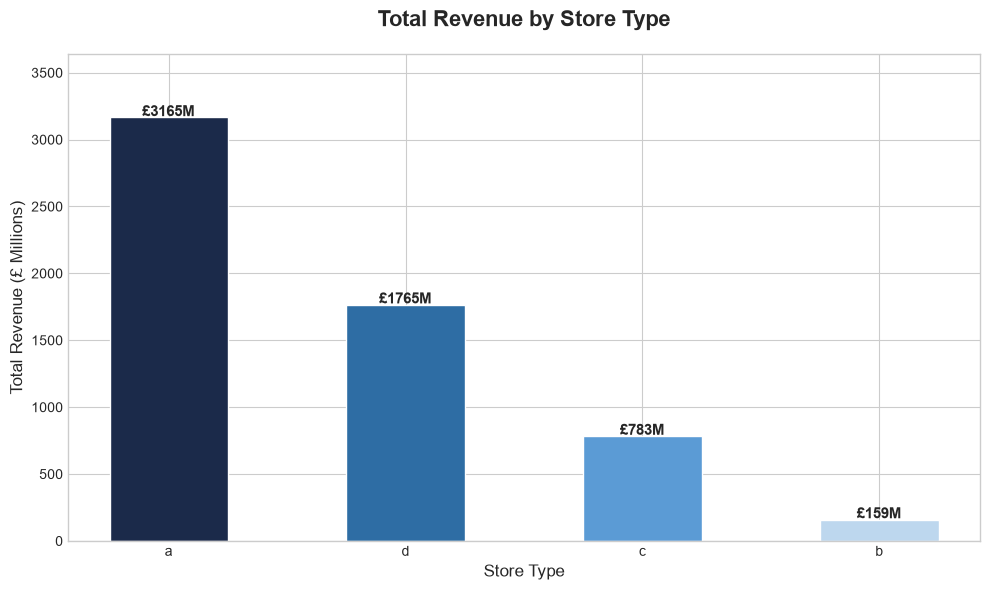

✅ Chart saved to outputs folder!


In [7]:
# Connect and get data
conn = sqlite3.connect('C:/cpg_project/cpg_retail.db')

query = """
SELECT 
    s.StoreType,
    SUM(t.Sales) AS total_revenue
FROM sales t
JOIN stores s ON t.Store = s.Store
WHERE t.Open = 1
GROUP BY s.StoreType
ORDER BY total_revenue DESC
"""

store_type_data = pd.read_sql_query(query, conn)
conn.close()

# Convert to millions for cleaner numbers
store_type_data['revenue_millions'] = store_type_data['total_revenue'] / 1_000_000

# Create the chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    store_type_data['StoreType'],
    store_type_data['revenue_millions'],
    color=['#1B2A4A', '#2E6DA4', '#5B9BD5', '#BDD7EE'],
    width=0.5,
    edgecolor='white'
)

# Add value labels on top of each bar
for bar, val in zip(bars, store_type_data['revenue_millions']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'£{val:.0f}M',
        ha='center',
        fontweight='bold',
        fontsize=11
    )

# Labels and title
ax.set_title('Total Revenue by Store Type', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Store Type', fontsize=12)
ax.set_ylabel('Total Revenue (£ Millions)', fontsize=12)
ax.set_ylim(0, store_type_data['revenue_millions'].max() * 1.15)

# Save the chart
plt.tight_layout()
plt.savefig('C:/cpg_project/outputs/chart1_revenue_by_store_type.png', dpi=150)
plt.show()

print("✅ Chart saved to outputs folder!")

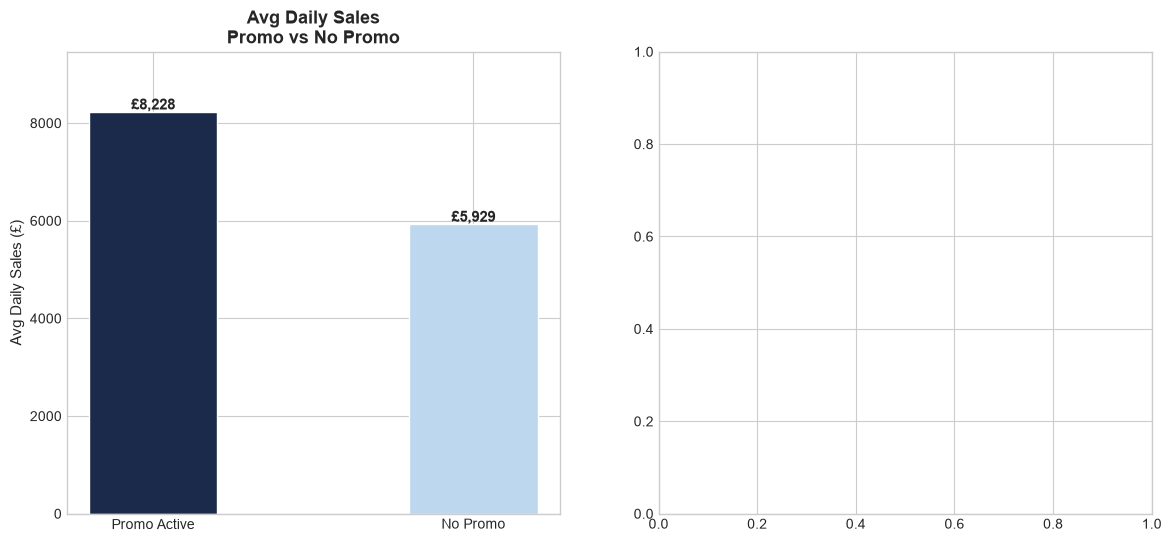

In [8]:
# Connect and get data
conn = sqlite3.connect('C:/cpg_project/cpg_retail.db')

query = """
SELECT 
    CASE WHEN Promo = 1 THEN 'Promo Active' 
         ELSE 'No Promo' END AS promotion_status,
    ROUND(AVG(Sales), 2)     AS avg_daily_sales,
    ROUND(AVG(Customers), 2) AS avg_customers
FROM sales
WHERE Open = 1
GROUP BY Promo
ORDER BY avg_daily_sales DESC
"""

promo_data = pd.read_sql_query(query, conn)
conn.close()

# Create side by side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Chart: Avg Daily Sales ---
bars1 = axes[0].bar(
    promo_data['promotion_status'],
    promo_data['avg_daily_sales'],
    color=['#1B2A4A', '#BDD7EE'],
    width=0.4,
    edgecolor='white'
)

for bar, val in zip(bars1, promo_data['avg_daily_sales']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'£{val:,.0f}',
        ha='center',
        fontweight='bold',
        fontsize=11
    )

axes[0].set_title('Avg Daily Sales\nPromo vs No Promo', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Daily Sales (£)', fontsize=11)
axes[0].set_ylim(0, promo_data['avg_daily_sales'].max() * 1.15)

# --- Right Chart: Avg Customers ---
bar

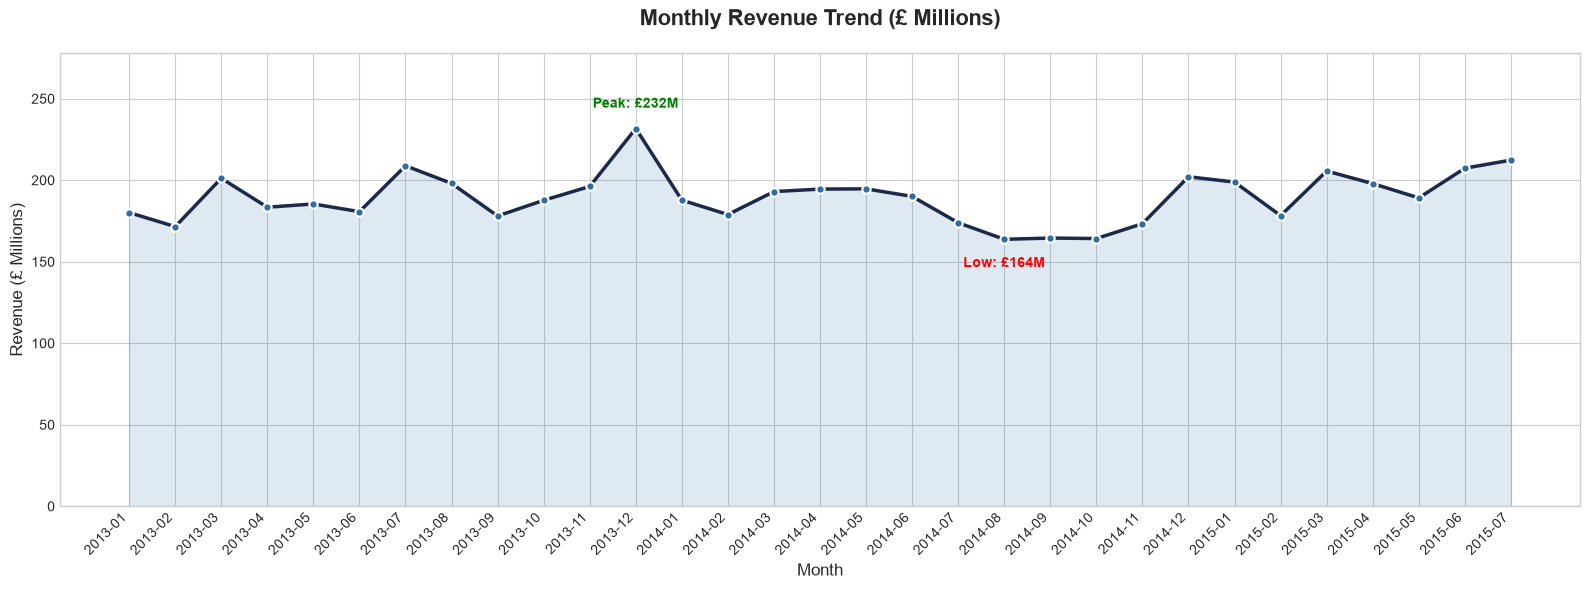

✅ Chart 3 saved to outputs folder!
📈 Peak Month: 2013-12 — £232M
📉 Lowest Month: 2014-08 — £164M


In [9]:
# Connect and get data
conn = sqlite3.connect('C:/cpg_project/cpg_retail.db')

query = """
SELECT 
    strftime('%Y-%m', Date) AS month,
    SUM(Sales)              AS monthly_revenue,
    SUM(Customers)          AS monthly_customers,
    ROUND(AVG(Sales), 2)    AS avg_daily_sales
FROM sales
WHERE Open = 1
GROUP BY month
ORDER BY month
"""

monthly_data = pd.read_sql_query(query, conn)
conn.close()

# Convert revenue to millions
monthly_data['revenue_millions'] = monthly_data['monthly_revenue'] / 1_000_000

# Create the chart
fig, ax = plt.subplots(figsize=(16, 6))

# Plot the line
ax.plot(
    monthly_data['month'],
    monthly_data['revenue_millions'],
    color='#1B2A4A',
    linewidth=2.5,
    marker='o',
    markersize=6,
    markerfacecolor='#2E6DA4',
    markeredgecolor='white',
    markeredgewidth=1.5
)

# Shade area under the line
ax.fill_between(
    monthly_data['month'],
    monthly_data['revenue_millions'],
    alpha=0.15,
    color='#2E6DA4'
)

# Highlight highest and lowest months
max_idx = monthly_data['revenue_millions'].idxmax()
min_idx = monthly_data['revenue_millions'].idxmin()

# Highest point
ax.annotate(
    f"Peak: £{monthly_data.loc[max_idx, 'revenue_millions']:.0f}M",
    xy=(monthly_data.loc[max_idx, 'month'], 
        monthly_data.loc[max_idx, 'revenue_millions']),
    xytext=(0, 15),
    textcoords='offset points',
    ha='center',
    fontweight='bold',
    color='green',
    fontsize=10
)

# Lowest point
ax.annotate(
    f"Low: £{monthly_data.loc[min_idx, 'revenue_millions']:.0f}M",
    xy=(monthly_data.loc[min_idx, 'month'], 
        monthly_data.loc[min_idx, 'revenue_millions']),
    xytext=(0, -20),
    textcoords='offset points',
    ha='center',
    fontweight='bold',
    color='red',
    fontsize=10
)

# Labels and title
ax.set_title('Monthly Revenue Trend (£ Millions)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue (£ Millions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.set_ylim(0, monthly_data['revenue_millions'].max() * 1.2)

plt.tight_layout()
plt.savefig('C:/cpg_project/outputs/chart3_monthly_revenue_trend.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 3 saved to outputs folder!")
print(f"📈 Peak Month: {monthly_data.loc[max_idx, 'month']} — £{monthly_data.loc[max_idx, 'revenue_millions']:.0f}M")
print(f"📉 Lowest Month: {monthly_data.loc[min_idx, 'month']} — £{monthly_data.loc[min_idx, 'revenue_millions']:.0f}M")

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("✅ Machine Learning libraries loaded!")
print("Ready for clustering!")

✅ Machine Learning libraries loaded!
Ready for clustering!


In [11]:
# Connect and get store level data
conn = sqlite3.connect('C:/cpg_project/cpg_retail.db')

query = """
SELECT 
    t.Store,
    AVG(t.Sales)                                    AS avg_daily_sales,
    SUM(t.Sales)                                    AS total_revenue,
    AVG(t.Customers)                                AS avg_customers,
    AVG(t.Promo)                                    AS promo_rate,
    SUM(t.Sales) * 1.0 / NULLIF(SUM(t.Customers),0) AS revenue_per_customer
FROM sales t
WHERE t.Open = 1
GROUP BY t.Store
"""

store_features = pd.read_sql_query(query, conn)
conn.close()

print(f"✅ Data loaded for {len(store_features)} stores!")
print()
print("Sample data:")
print(store_features.head())

✅ Data loaded for 1115 stores!

Sample data:
   Store  avg_daily_sales  total_revenue  avg_customers  promo_rate  \
0      1      4759.096031        3716854     564.049936    0.448143   
1      2      4953.900510        3883858     583.998724    0.451531   
2      3      6942.568678        5408261     750.077022    0.449294   
3      4      9638.401786        7556507    1321.752551    0.450255   
4      5      4676.274711        3642818     537.340180    0.450578   

   revenue_per_customer  
0              8.437366  
1              8.482725  
2              9.255808  
3              7.292138  
4              8.702634  


In [12]:
# Step 1 — Scale the data
features = ['avg_daily_sales', 'total_revenue', 'avg_customers', 
            'promo_rate', 'revenue_per_customer']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(store_features[features])

print("✅ Data scaled successfully!")
print()

# Step 2 — Find optimal K using Elbow Method
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"K={k} — Silhouette Score: {silhouette_score(X_scaled, km.labels_):.3f}")

print()
print("✅ Optimal K analysis done!")

✅ Data scaled successfully!

K=2 — Silhouette Score: 0.472
K=3 — Silhouette Score: 0.399
K=4 — Silhouette Score: 0.322
K=5 — Silhouette Score: 0.334
K=6 — Silhouette Score: 0.339
K=7 — Silhouette Score: 0.321
K=8 — Silhouette Score: 0.319

✅ Optimal K analysis done!


In [13]:
# Apply K-Means with K=2
optimal_k = 2
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
store_features['Cluster'] = km_final.fit_predict(X_scaled)

# Label clusters based on avg daily sales
cluster_avg = store_features.groupby('Cluster')['avg_daily_sales'].mean()
high_cluster = cluster_avg.idxmax()
low_cluster = cluster_avg.idxmin()

store_features['Cluster_Label'] = store_features['Cluster'].map({
    high_cluster: 'High Performers',
    low_cluster:  'Low Performers'
})

# Show cluster summary
summary = store_features.groupby('Cluster_Label').agg(
    num_stores=('Store', 'count'),
    avg_daily_sales=('avg_daily_sales', 'mean'),
    avg_revenue=('total_revenue', 'mean'),
    avg_customers=('avg_customers', 'mean'),
    avg_promo_rate=('promo_rate', 'mean')
).round(2)

print("✅ Clustering done!")
print()
print("Cluster Summary:")
print(summary)
print()
print(f"Silhouette Score: {silhouette_score(X_scaled, store_features['Cluster']):.3f}")

✅ Clustering done!

Cluster Summary:
                 num_stores  avg_daily_sales  avg_revenue  avg_customers  \
Cluster_Label                                                              
High Performers         192         10580.98   8276781.30        1300.00   
Low Performers          923          6175.62   4641428.62         641.04   

                 avg_promo_rate  
Cluster_Label                    
High Performers            0.44  
Low Performers             0.45  

Silhouette Score: 0.472


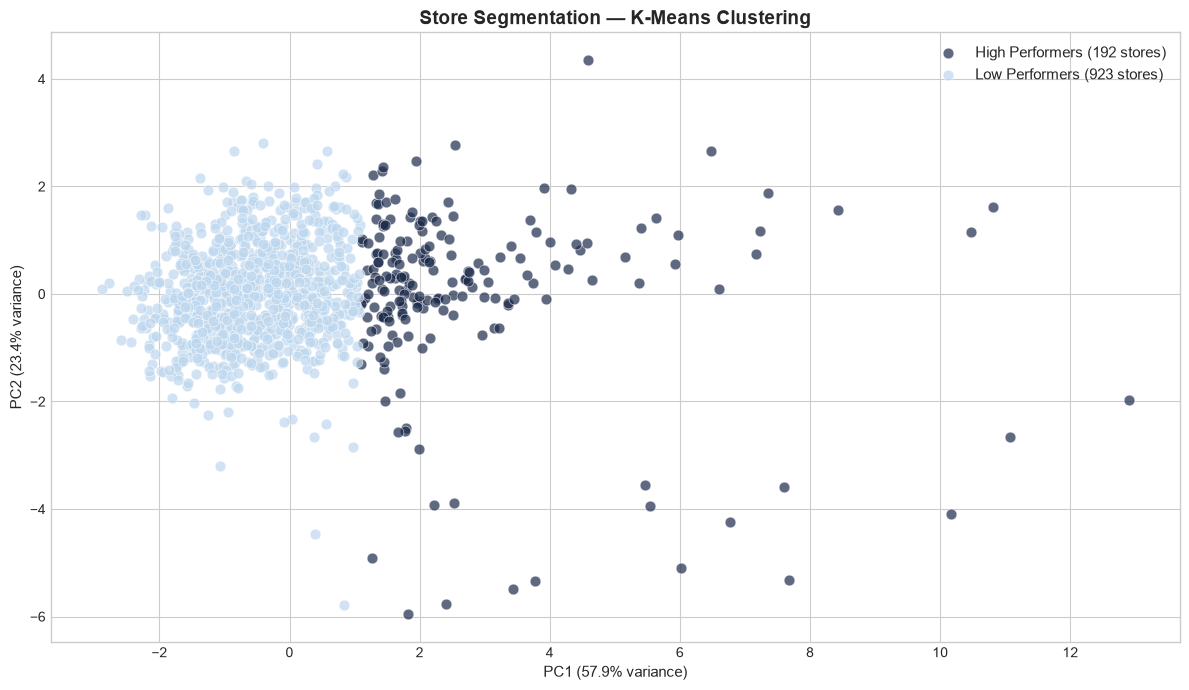

✅ Cluster chart saved!
PC1 explains 57.9% of variance
PC2 explains 23.4% of variance
Together: 81.2% of variance explained


In [15]:
# PCA to visualise clusters in 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 7))

colors = {'High Performers': '#1B2A4A', 'Low Performers': '#BDD7EE'}

for label, color in colors.items():
    mask = store_features['Cluster_Label'] == label
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=color,
        label=f"{label} ({mask.sum()} stores)",
        alpha=0.7,
        s=60,
        edgecolors='white',
        linewidth=0.5
    )

ax.set_title('Store Segmentation — K-Means Clustering', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('C:/cpg_project/outputs/chart4_store_clusters.png', dpi=150)
plt.show()

print("✅ Cluster chart saved!")
print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"Together: {sum(pca.explained_variance_ratio_)*100:.1f}% of variance explained")

In [16]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import LabelEncoder

print("✅ XGBoost and ML libraries loaded!")
print("Ready to build demand forecasting model!")

✅ XGBoost and ML libraries loaded!
Ready to build demand forecasting model!


In [17]:
# Connect and load data
conn = sqlite3.connect('C:/cpg_project/cpg_retail.db')

query = """
SELECT 
    t.Store,
    t.Date,
    t.Sales,
    t.Customers,
    t.Promo,
    t.SchoolHoliday,
    t.DayOfWeek,
    t.StateHoliday,
    s.StoreType,
    s.Assortment,
    s.CompetitionDistance
FROM sales t
JOIN stores s ON t.Store = s.Store
WHERE t.Open = 1 AND t.Sales > 0
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Feature Engineering — extract date parts
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Day']        = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)
df['Quarter']    = df['Date'].dt.quarter

# Encode text columns into numbers
le = LabelEncoder()
df['StoreType_enc']    = le.fit_transform(df['StoreType'].fillna('Unknown'))
df['Assortment_enc']   = le.fit_transform(df['Assortment'].fillna('Unknown'))
df['StateHoliday_enc'] = le.fit_transform(df['StateHoliday'].astype(str))

# Fill missing competition distance with median
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(
    df['CompetitionDistance'].median()
)

print("✅ Data loaded and features engineered!")
print(f"Total records: {len(df):,}")
print()
print("Features created:")
print("Date parts — Year, Month, Day, WeekOfYear, IsWeekend, Quarter")
print("Encoded    — StoreType, Assortment, StateHoliday")
print("Original   — Store, DayOfWeek, Promo, SchoolHoliday, CompetitionDistance")

✅ Data loaded and features engineered!
Total records: 844,338

Features created:
Date parts — Year, Month, Day, WeekOfYear, IsWeekend, Quarter
Encoded    — StoreType, Assortment, StateHoliday
Original   — Store, DayOfWeek, Promo, SchoolHoliday, CompetitionDistance


In [23]:
# Define features and target
features = [
    'Store', 'DayOfWeek', 'Promo', 'SchoolHoliday',
    'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'Quarter',
    'StoreType_enc', 'Assortment_enc', 'StateHoliday_enc',
    'CompetitionDistance'
]

X = df[features]
y = df['Sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, shuffle=False
)

print(f"✅ Data split done!")
print(f"Training : {len(X_train):,}")
print(f"Testing  : {len(X_test):,}")
print()

# Baseline
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mape = mean_absolute_percentage_error(y_test, baseline_pred) * 100
print(f"Baseline Accuracy: {100 - baseline_mape:.1f}%")
print()
print("Training XGBoost... please wait 2-3 minutes...")

# Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)
y_pred = np.maximum(y_pred, 0)

# Results
xgb_mape = mean_absolute_percentage_error(y_test, y_pred) * 100
xgb_r2   = r2_score(y_test, y_pred)
improvement = baseline_mape - xgb_mape

print()
print("=" * 45)
print("         MODEL RESULTS")
print("=" * 45)
print(f"Baseline Accuracy  : {100 - baseline_mape:.1f}%")
print(f"XGBoost Accuracy   : {100 - xgb_mape:.1f}%")
print(f"Improvement        : +{improvement:.1f} percentage points")
print(f"R² Score           : {xgb_r2:.3f}")
print("=" * 45)

✅ Data split done!
Training : 717,687
Testing  : 126,651

Baseline Accuracy: 55.8%

Training XGBoost... please wait 2-3 minutes...

         MODEL RESULTS
Baseline Accuracy  : 55.8%
XGBoost Accuracy   : 75.8%
Improvement        : +20.1 percentage points
R² Score           : 0.629


In [22]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split
import xgboost as xgb

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


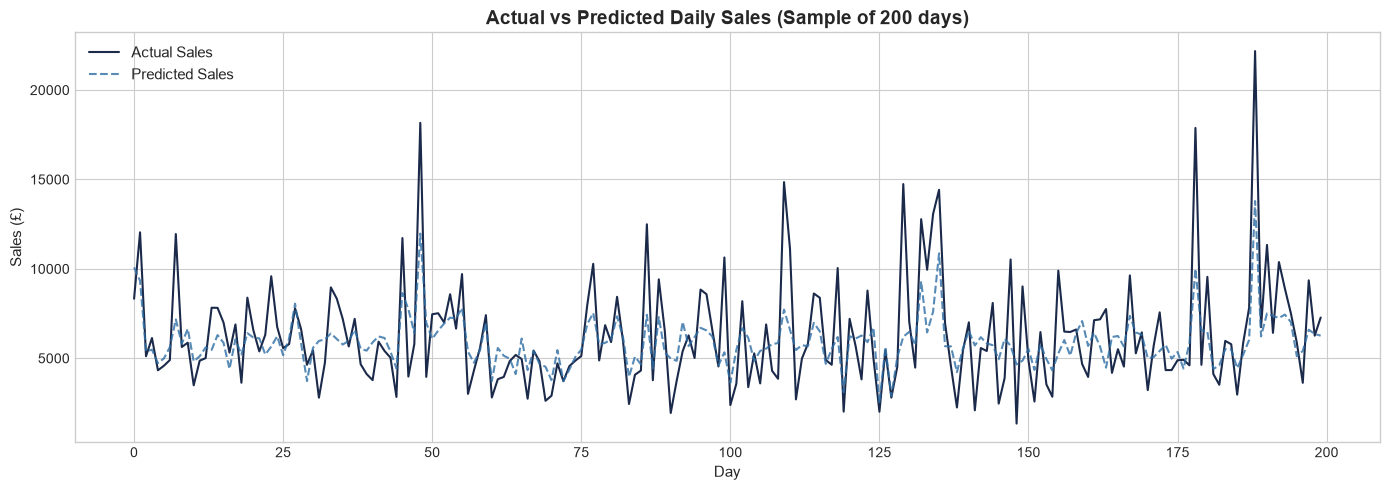

✅ Chart 5 saved!

✅ Forecast results saved to CSV!
Ready to load into Power BI!


In [24]:
# Create Actual vs Predicted Chart
sample = 200

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(range(sample), 
        y_test.values[:sample], 
        label='Actual Sales', 
        color='#1B2A4A', 
        linewidth=1.5)

ax.plot(range(sample), 
        y_pred[:sample], 
        label='Predicted Sales',
        color='#2E6DA4',
        linestyle='--', 
        linewidth=1.5, 
        alpha=0.8)

ax.set_title('Actual vs Predicted Daily Sales (Sample of 200 days)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Day', fontsize=11)
ax.set_ylabel('Sales (£)', fontsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('C:/cpg_project/outputs/chart5_actual_vs_predicted.png', dpi=150)
plt.show()

print("✅ Chart 5 saved!")
print()

# Save predictions to CSV for Power BI
results_df = pd.DataFrame({
    'Actual_Sales'   : y_test.values,
    'Predicted_Sales': y_pred
})
results_df.to_csv('C:/cpg_project/outputs/forecast_results.csv', index=False)
print("✅ Forecast results saved to CSV!")
print("Ready to load into Power BI!")